### 1. load csv standardised all

### 2. split in training and test data

### 3. define weight tensor

### 4. create gradient descent

### 5. create test function

### 6. define evaluation process

In [76]:
import pandas as pd
import numpy as np

In [2]:
import numpy as np
import pandas as pd

# Standardize using train mean & std
def standardize(X, mean=None, std=None):
    if mean is None:
        mean = X.mean(axis=0)
    if std is None:
        std = X.std(axis=0)
    return (X - mean) / std, mean, std

# Add bias column
def add_bias(X):
    ones = np.ones((X.shape[0],1))
    return np.hstack((ones, X))

class LinearRegressionScratch:
    def __init__(self, learning_rate, batchSize, features, labels):
        self.learning_rate = learning_rate
        self.weights = np.zeros((features.shape[1], 1))
        self.features = features
        self.labels = labels
        self.mseHistory = []
        self.batchSize = batchSize
        self.weightHistory = []   # NEW

    def gradientDescent(self, features,labels):
        predictions = features @ self.weights
        error = predictions - labels
        slopes = (features.T @ error) / features.shape[0]
        self.weights -= self.learning_rate * slopes


    def test(self, features, labels, log=False):
        predictions = features @ self.weights

        if log:
            for i in range(predictions.shape[0]):
                print(f"Pred: {predictions[i][0]:.2f} , Act: {labels[i][0]:.2f}")

        mse = ((predictions-labels)**2).mean()
        
        print("Test MSE: ", mse)

        r2 = self.cod(predictions, labels)
        print("R²:", r2)

    def cod(self, predictions, labels):
        ss_red = ((labels - predictions)**2).sum()
        ss_tot = ((labels - labels.mean())**2).sum()
        return 1 - (ss_red / ss_tot)

    
    def batch(self, epochs):
        n = self.features.shape[0]

        for epoch in range(epochs):

            idx = np.random.permutation(n)
            X = self.features[idx]
            y = self.labels[idx]
            
            for start in range(0, n, self.batchSize):

                end = start + self.batchSize
                Xb = X[start:end]
                yb = y[start:end]

                self.gradientDescent(features=Xb,labels=yb)

            self.weightHistory.append(self.weights.copy())
            crtMse = (((self.features @ self.weights) - self.labels)**2).mean()

            if len(self.mseHistory) > 0:
                if crtMse > self.mseHistory[-1]:
                    self.learning_rate /= 2  # reduce if MSE increases
                else:
                    self.learning_rate *= 1.01  # slightly increase if MSE decreases
            
            # if len(self.mseHistory) > 50 and abs(self.mseHistory[-1] - self.mseHistory[-50]) < 1e-6:
            #     break;
            self.mseHistory.append(crtMse)


# -------------------
# Load dataset
cars = pd.read_csv("./cars.csv")
cars = cars.sample(frac=1).reset_index(drop=True)  # shuffle

# Split train/test
split_ratio = 0.7
split_index = int(len(cars) * split_ratio)
train = cars[:split_index]
test = cars[split_index:]
print("testShape",test.shape)
print("trainShape",train.shape)
# Features and target
feature_list = ['horsepower','weight','cylinders','acceleration','displacement']
y_train = train['mpg'].values.reshape(-1,1)
y_test = test['mpg'].values.reshape(-1,1)
 
# Standardize using train stats
X_train_std, train_mean, train_std = standardize(train[feature_list].values)
X_test_std, _, _ = standardize(test[feature_list].values, mean=train_mean, std=train_std)

# Add bias
X_train = add_bias(X_train_std)
X_test = add_bias(X_test_std)

# Initialize and train
model = LinearRegressionScratch(
    learning_rate=0.05,
    features=X_train,
    labels=y_train,
    batchSize=3
)

# model.fit(clear_weight=False)
model.batch(epochs=30)
print(len(model.mseHistory))
model.test(features=X_test, labels=y_test, log=False)

testShape (118, 9)
trainShape (274, 9)
30
Test MSE:  14.980805279720114
R²: 0.7034451143726326


### Learning rate optimisation techniques

1. Adam
2. Adagrad
3. RMSProp
4. Momentum

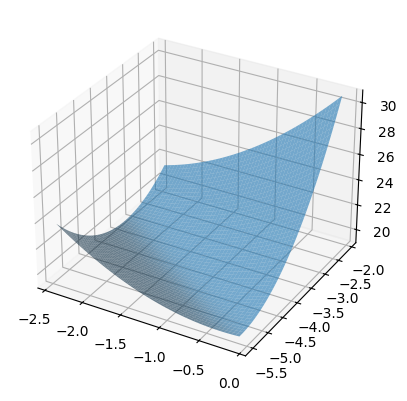

In [3]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# choose two weights to visualize
w1_vals = [w[1,0] for w in model.weightHistory]
w2_vals = [w[2,0] for w in model.weightHistory]

w1_range = np.linspace(min(w1_vals)-1, max(w1_vals)+1, 50)
w2_range = np.linspace(min(w2_vals)-1, max(w2_vals)+1, 50)

W1, W2 = np.meshgrid(w1_range, w2_range)
Z = np.zeros_like(W1)

# compute MSE surface
for i in range(W1.shape[0]):
    for j in range(W1.shape[1]):
        temp_w = model.weights.copy()
        temp_w[1,0] = W1[i,j]
        temp_w[2,0] = W2[i,j]
        preds = model.features @ temp_w
        Z[i,j] = ((preds - model.labels)**2).mean()

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(W1, W2, Z, alpha=0.6)

point, = ax.plot([], [], [], 'ro')

def update(frame):
    w1 = w1_vals[frame]
    w2 = w2_vals[frame]
    mse = model.mseHistory[frame]
    point.set_data([w1],[w2])
    point.set_3d_properties([mse])
    return point,

ani = FuncAnimation(fig, update, frames=len(w1_vals), interval=300)

plt.show()

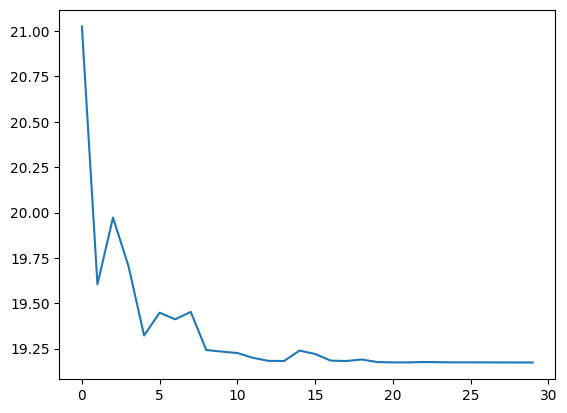

In [5]:
plt.plot(model.mseHistory)
plt.show()